### importing library required for this project

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score,recall_score,precision_score,confusion_matrix,classification_report,roc_auc_score,precision_recall_curve
from sklearn.model_selection import train_test_split,RandomizedSearchCV,GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import cross_val_score
import pickle
# from ydata_profiling import ProfileReport
import warnings
warnings.filterwarnings('ignore')

### loading data from csv file

In [2]:
df=pd.read_csv('Churn_Modelling.csv')

### Understanding data

In [3]:
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
5473,5474,15596863,Chidumaga,787,Germany,Female,38,3,158373.23,1,1,1,28228.35,0
6545,6546,15572735,Chang,433,Spain,Male,27,2,0.00,2,1,1,153698.65,0
5357,5358,15691396,Ko,405,Germany,Male,31,5,133299.67,2,1,1,72950.14,0
397,398,15612187,Morin,547,Germany,Male,32,8,155726.85,1,1,0,67789.99,0
8851,8852,15590828,Chidimma,782,Germany,Male,42,7,126428.38,1,1,0,39830.10,0


In [4]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

df.info()

In [6]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [7]:
df.shape
print('The number of rows:',df.shape[0])
print('The number of columns:',df.shape[1])

The number of rows: 10000
The number of columns: 14


### Pandas Profiling

In [8]:
# temp=ProfileReport(df)
# temp.to_file(output_file='output.html')

### Cleaning data

In [9]:
## droping column rowid,surname which is not necessary for predicting customer churn rate
df=df.drop(columns=['RowNumber','Surname','CustomerId'])

### In this data we have not misssing value or duplicated row and data till analysis is clearn,furhter we will perform EDA 

## EDA

### Univariate Anlaysis
### CreditScore Column Analaysis

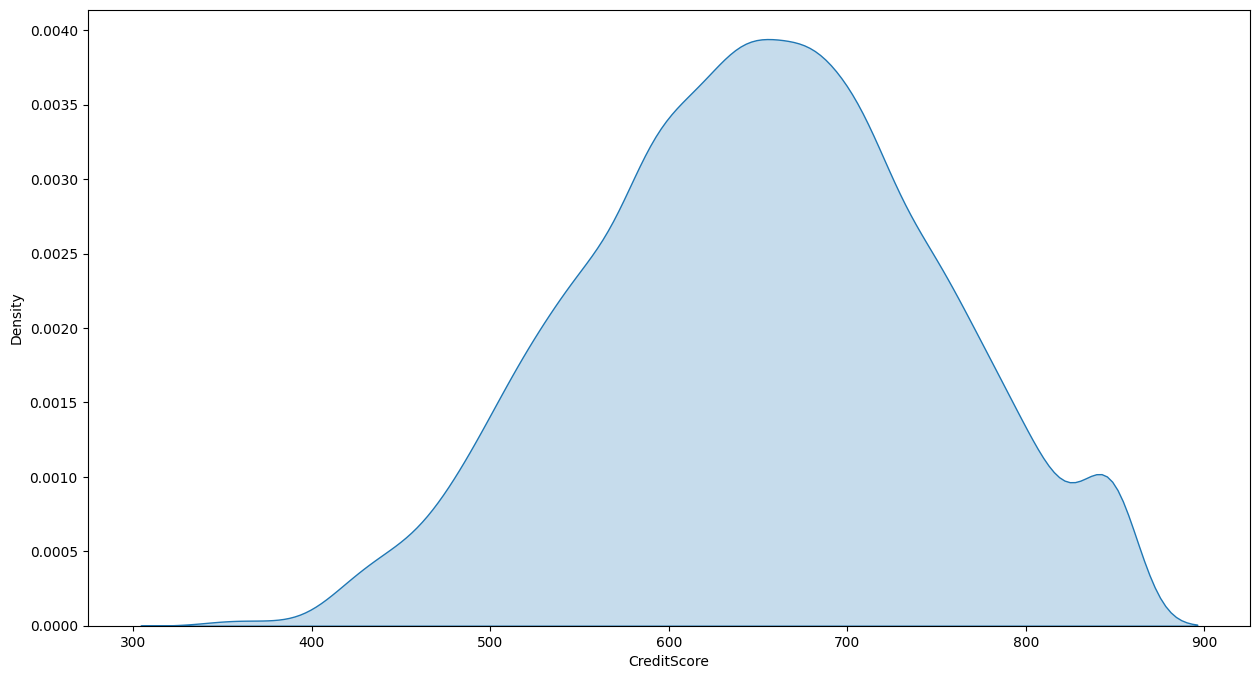

In [10]:
plt.figure(figsize=(15,8))
sns.kdeplot(data=df,x='CreditScore',fill=True)
plt.show()

(array([  19.,  166.,  447.,  958., 1444., 1866., 1952., 1525.,  968.,
         655.]),
 array([350., 400., 450., 500., 550., 600., 650., 700., 750., 800., 850.]),
 <BarContainer object of 10 artists>)

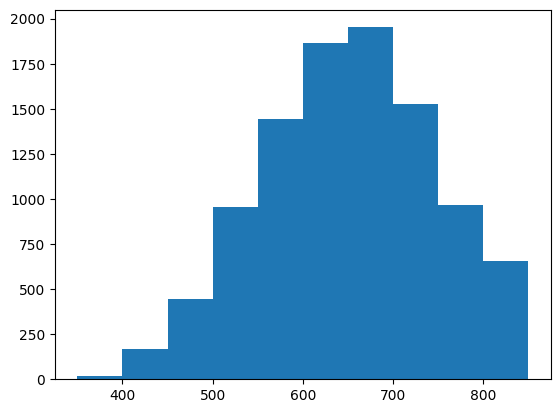

In [11]:
plt.hist(df['CreditScore'])

In [12]:
df['CreditScore'].skew()

np.float64(-0.07160660820092675)

In [13]:
upper_value=df['CreditScore'].mean()+3*df['CreditScore'].std()

In [14]:
lower_value=df['CreditScore'].mean()-3*df['CreditScore'].std()

In [15]:
df[(df['CreditScore']<lower_value )|(df['CreditScore']>upper_value)]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1405,359,France,Female,44,6,128747.69,1,1,0,146955.71,1
1631,350,Spain,Male,54,1,152677.48,1,1,1,191973.49,1
1838,350,Germany,Male,39,0,109733.20,2,0,0,123602.11,1
1962,358,Spain,Female,52,8,143542.36,3,1,0,141959.11,1
2473,351,Germany,Female,57,4,163146.46,1,1,0,169621.69,1
8723,350,France,Male,51,10,0.00,1,1,1,125823.79,1
8762,350,France,Female,60,3,0.00,1,0,0,113796.15,1
9624,350,France,Female,40,0,111098.85,1,1,1,172321.21,1


In [16]:
df['CreditScore']=np.where(df['CreditScore']>upper_value,upper_value,np.where(df['CreditScore']<lower_value,lower_value,df['CreditScore']))

In [17]:
df[(df['CreditScore']<lower_value )|(df['CreditScore']>upper_value)]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


### Insight:
* The data can be assumped roughly normal distributed(i.e, skew value is -0.07).
* The data contain outlier value
* We handle outlier value using z-test startegy because the data is a roughly normal distributed.

### Geography column Analysis

In [18]:
result=df['Geography'].value_counts()

<Axes: xlabel='Geography'>

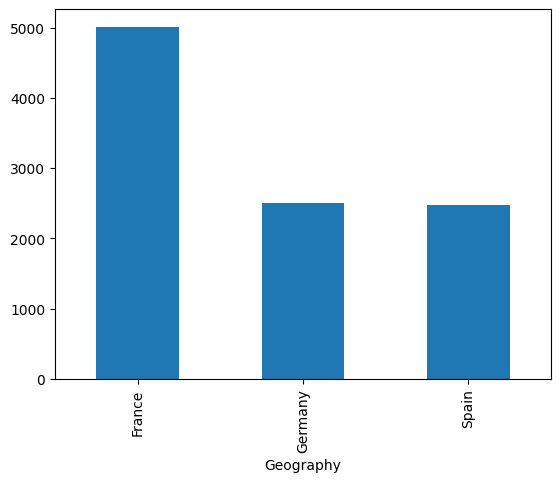

In [19]:
result.plot(kind='bar')

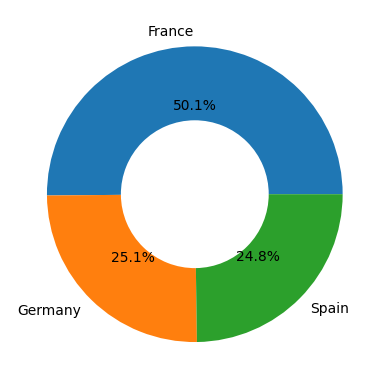

In [20]:
result.plot(kind='pie',autopct='%1.1f%%',wedgeprops={'width':0.5})
plt.show()

### Insight:
* The dataset contain data of three different country.
* The dataset is dominated by France, which has the highest number of records. Germany and Spain contribute approximately half as many records as France, with similar representation between them

### Gender Column Analysis

In [21]:
result=df['Gender'].value_counts().reset_index(name='Total')
result

,Gender,Total
0,Male,5457
1,Female,4543


<BarContainer object of 2 artists>

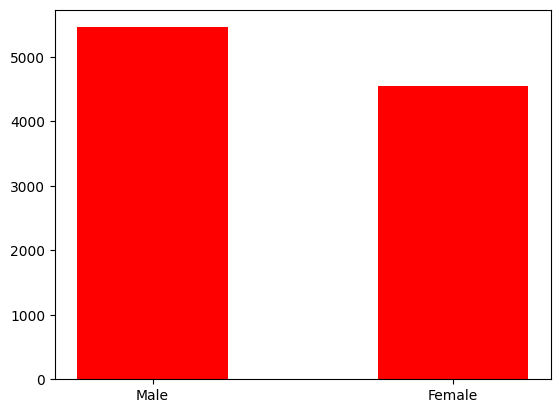

In [22]:
plt.bar(result['Gender'],result['Total'],color='red',width=0.5)

### Insight:
* The data in dataset contain record of  male are more than female with margin of around 1000 

### Age Column

<Axes: ylabel='Density'>

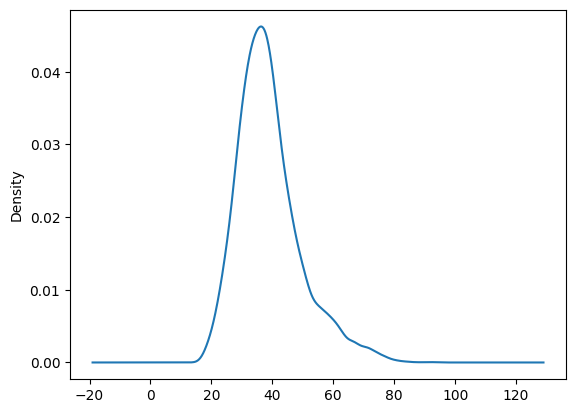

In [23]:
df['Age'].plot(kind='kde')

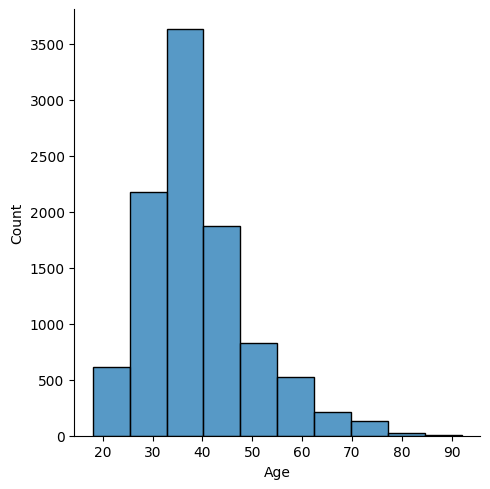

In [24]:
sns.displot(kind='hist',data=df,x='Age',bins=10)
plt.show()

<Axes: ylabel='Age'>

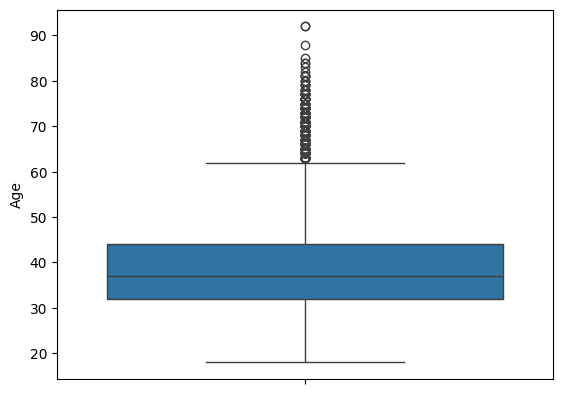

In [25]:
sns.boxplot(df['Age'])

In [26]:
df['Age'].skew()

np.float64(1.0113202630234552)

In [27]:
q3=df['Age'].quantile(0.75)
q3

np.float64(44.0)

In [28]:
q1=df['Age'].quantile(0.25)
q1

np.float64(32.0)

In [29]:
iqr=q3-q1
lower_limit=q1-1.5*iqr
upper_limit=q3+1.5*iqr

In [30]:
df[(df['Age']<lower_limit)|(df['Age']>upper_limit)]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
58,511.0,Spain,Female,66,4,0.00,1,1,0,1643.11,1
85,652.0,Spain,Female,75,10,0.00,2,1,1,114675.75,0
104,670.0,Spain,Female,65,1,0.00,1,1,1,177655.68,1
158,646.0,France,Female,73,6,97259.25,1,0,1,104719.66,0
181,510.0,France,Male,65,2,0.00,2,1,1,48071.61,0
...,...,...,...,...,...,...,...,...,...,...,...
9753,656.0,Germany,Male,68,7,153545.11,1,1,1,186574.68,0
9765,445.0,France,Male,64,2,136770.67,1,0,1,43678.06,0
9832,595.0,Germany,Female,64,2,105736.32,1,1,1,89935.73,1
9894,521.0,France,Female,77,6,0.00,2,1,1,49054.10,0


### Insight:
* The data in Age column is right skewed.
* Maximum people have age between **35-40**.
* I also check outlier value but the age value are valid we should not consider it as outliers

### Tenure Column Analysis

In [31]:
result=df['Tenure'].value_counts().sort_values()
result

Tenure
0      413
10     490
6      967
9      984
4      989
3     1009
5     1012
8     1025
7     1028
1     1035
2     1048
Name: count, dtype: int64

<Axes: xlabel='Tenure'>

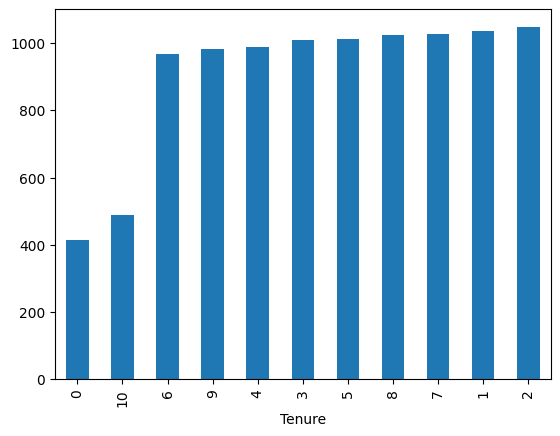

In [32]:
result.plot(kind='bar')

### Insight:
* Most customers remain with the bank for 1–9 years, showing strong  loyalty to the bank.
* A small segment leaves within the first year, indicating satisfaction issues or may have other issue.
*  A notable group has stayed for 10+ years, reflecting deep trust and stable relationships with the bank.

### Balance Column Analysis

<Axes: ylabel='Density'>

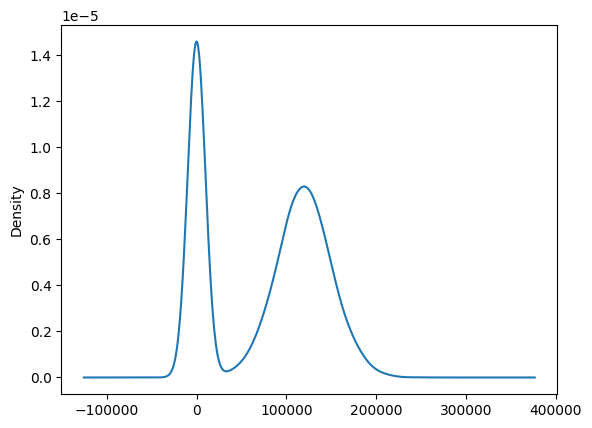

In [33]:
df['Balance'].plot(kind='kde')

<Axes: ylabel='Frequency'>

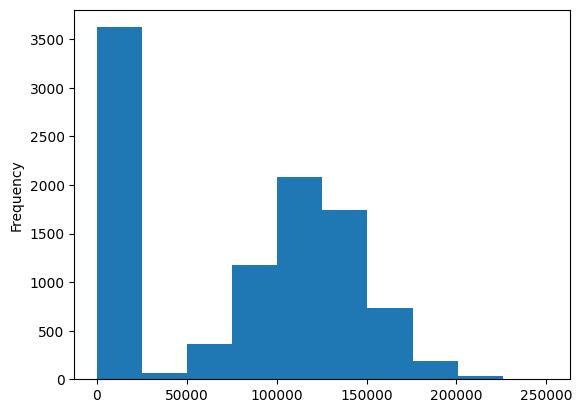

In [34]:
df['Balance'].plot(kind='hist')

In [35]:
df['Balance'].skew()

np.float64(-0.14110871094154379)

In [36]:
q1=df['Balance'].quantile(0.25)
q3=df['Balance'].quantile(0.75)
print(q1,q3)

0.0 127644.24


In [37]:
iqr=q3-q1
lower_limit=q1-1.5*iqr
upper_limit=q1+1.5*iqr
upper_limit

np.float64(191466.36000000002)

In [38]:
df[(df['Balance']<lower_limit)|(df['Balance']>upper_limit)]

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
138,584.0,Spain,Female,48,2,213146.20,1,1,0,75161.25,1
520,850.0,France,Female,35,1,211774.31,1,1,0,188574.12,1
656,549.0,Spain,Male,25,6,193858.20,1,0,1,21600.11,0
720,672.0,Spain,Female,56,2,209767.31,2,1,1,150694.42,1
932,708.0,Germany,Female,42,8,192390.52,2,1,0,823.36,0
980,594.0,France,Male,27,0,197041.80,1,0,0,151912.49,0
1067,650.0,Germany,Male,26,4,214346.96,2,1,0,128815.33,0
1174,705.0,Spain,Female,40,5,203715.15,1,1,0,179978.68,1
1365,625.0,France,Male,43,8,201696.07,1,1,0,133020.90,1
1533,850.0,France,Female,37,3,212778.20,1,0,1,69372.88,0


In [39]:
df['Balance'].sort_values(ascending=False).head(20)

2092    250898.09
3280    238387.56
8733    222267.63
3588    221532.80
6717    216109.88
1067    214346.96
138     213146.20
1533    212778.20
3920    212696.32
2709    212692.97
8702    212314.03
520     211774.31
7353    210433.08
720     209767.31
8794    209490.21
5871    208165.53
8027    207034.96
3150    206868.78
8982    206663.75
6913    206329.65
Name: Balance, dtype: float64

### Insight:
* The kdeplot of Balance columns shows that curve is peaked at two positin,showing data is bimodal and also right skewed data.
* We also have check outlier value using iqr method and it show's value but before capping or removing we cross check that value are actually outliers but when we check the value are normal not outlier.

In [40]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='str')

### NumOfProducts Column analysis

In [41]:
result=df['NumOfProducts'].value_counts()

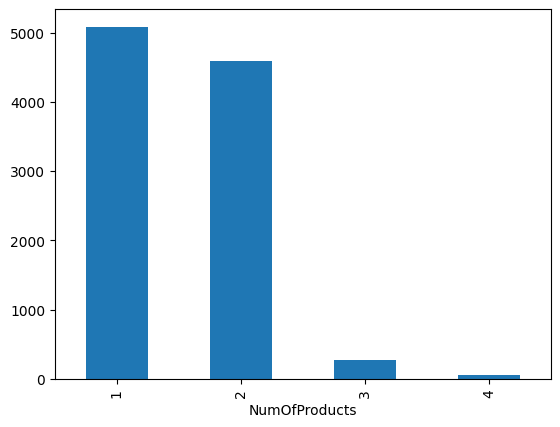

In [42]:
result.plot(kind='bar')
plt.show()

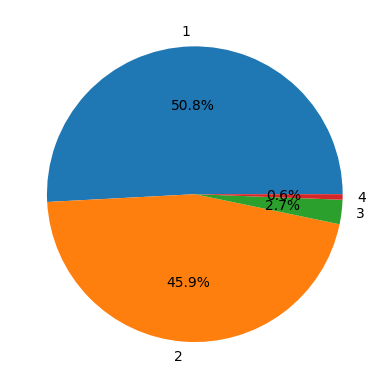

In [43]:
result.plot(kind='pie',autopct='%1.1f%%')
plt.show()

### Insights:
* Maximum Bank Customer around **50.8%** use only one features/Product of bank and also **45.9%** bank customer  used two bank features .
* Around **0.6%** of bank customer use maximum product/features of bank.
* We can interpret that there only few customer who used all 4 features of bank.

### HasCrCard Column Analysis

In [44]:
result=df['HasCrCard'].value_counts().reset_index()
result

,HasCrCard,count
0,1,7055
1,0,2945


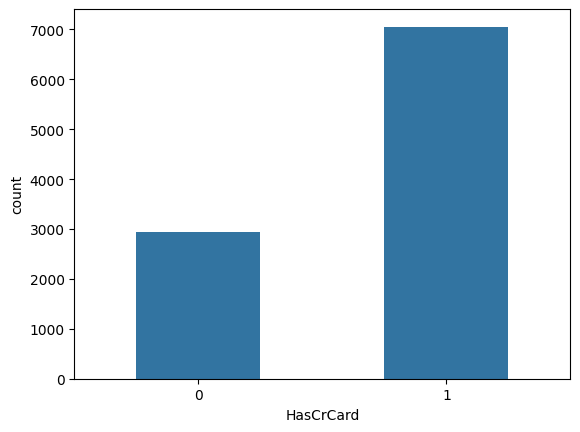

In [45]:
sns.barplot(data=result,x='HasCrCard',y='count',width=0.5)
plt.show()

### Insight:
* The dataset shows that customers with credit cards are about three times more numerous than those without.
* This suggests that credit card ownership is widespread among the customer base, and customers without cards form a relatively small segment.
* Preliminary observation indicates that credit card holders may be less likely to churn, since they are more engaged with the bank’s services, while non‑holders could represent a higher churn risk.
* However, further bivariate analysis with the target column (churn status) is required to confirm whether HasCrCard is a statistically significant predictor of churn.

### IsActiveMember Column Analysis

In [46]:
result=df['IsActiveMember'].value_counts().reset_index()
result

,IsActiveMember,count
0,1,5151
1,0,4849


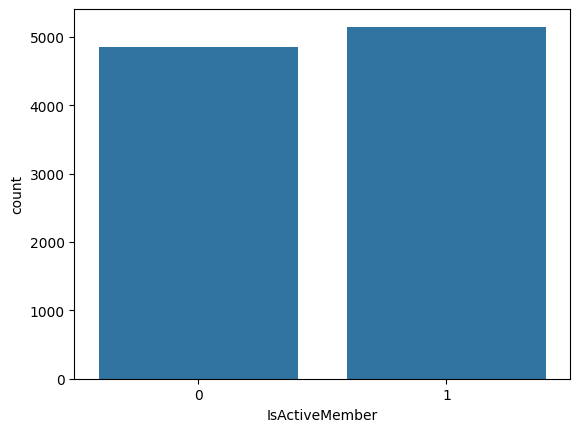

In [47]:
sns.barplot(data=result,x='IsActiveMember',y='count')
plt.show()

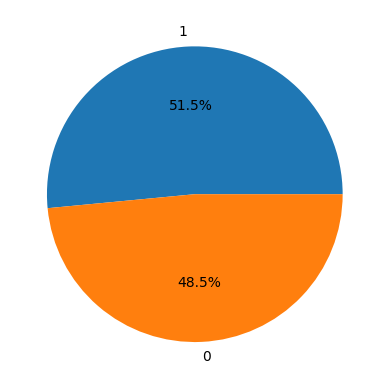

In [48]:
plt.pie(result['count'],labels=result['IsActiveMember'],autopct='%1.1f%%')
plt.show()

### Insights:
* The number of customer of bank who are actively using the bank services and cusomter who are not actively using the bank services are roughly similar.
* The customer of who are not using bank serivices actively are more likely to be churn where customer who are using bank servcies roughly are not likely to be churn
* This column may show strong factor for the to predict the churn rate of customer,further bivariae analysis will perform.

### EstimatedSalary Column Analysis

<Axes: xlabel='EstimatedSalary', ylabel='Density'>

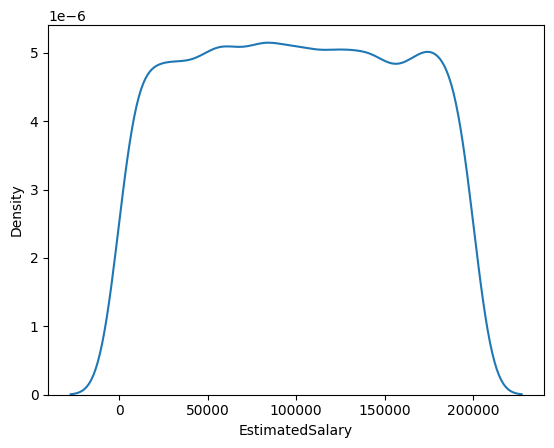

In [49]:
sns.kdeplot(data=df,x='EstimatedSalary')

<Axes: xlabel='EstimatedSalary', ylabel='Count'>

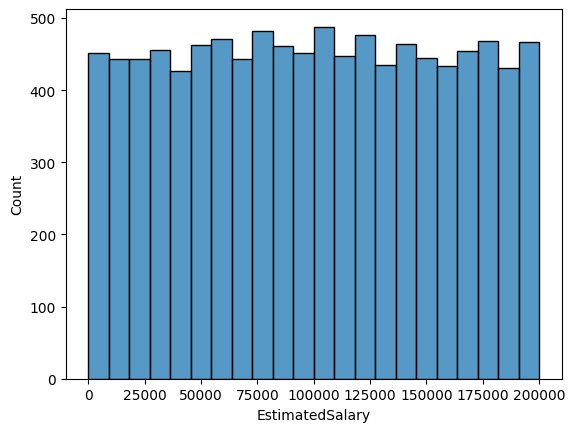

In [50]:
sns.histplot(data=df,x='EstimatedSalary')

<Axes: xlabel='EstimatedSalary'>

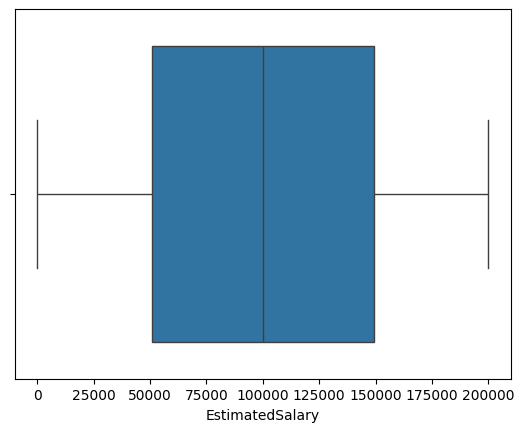

In [51]:
sns.boxplot(data=df,x='EstimatedSalary')

### Insights:
* The distribution of Estimated Salary is approximately uniform, meaning salaries are spread evenly across the entire range without concentration in any specific interval.
* The data shows no significant outliers or irregular patterns, indicating that the salary variable is clean and reliable for analysis.

### Exited Column Analysis

In [52]:
result=df['Exited'].value_counts()

<Axes: xlabel='Exited'>

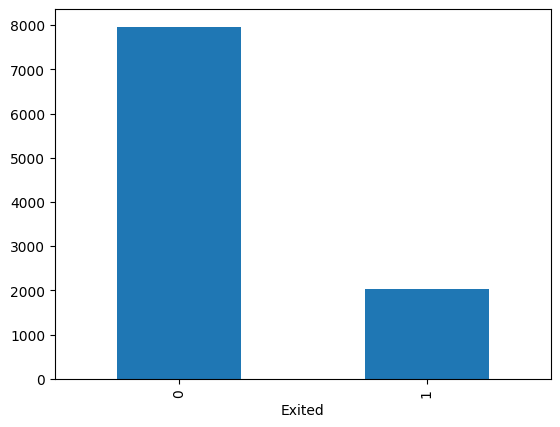

In [53]:
result.plot(kind='bar')

### Insights:
* The target column (Exited) shows that the dataset is imbalanced, with a significantly larger proportion of customers who stayed compared to those who churned.
* This imbalance is critical to note before modeling, because it can cause the model to be biased toward predicting the majority class (non‑churn).
* We can use various technique  like SMOOTH,assigning weight to handle imbalanced.

### Bivariate Analaysis
### CreditScore and Exited column anlaysis together

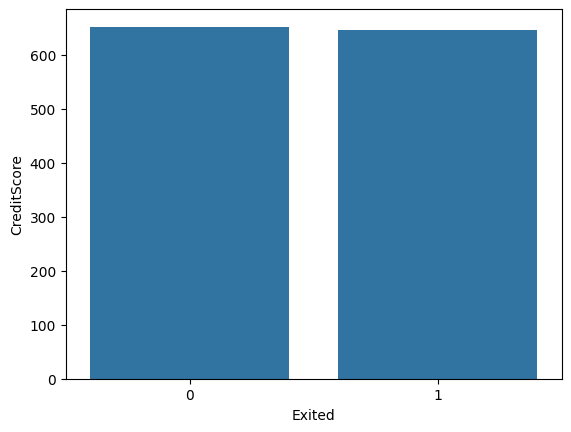

In [54]:
sns.barplot(data=df,x='Exited',y='CreditScore',errorbar=None)
plt.show()

In [55]:
## using statistics  Mann–Whitney U test
#H0:There is no significat difference between exited and not exited customer on creditscore distribution 
#H1:There is  significant difference between exited and not exitded customer on credit distribution

In [56]:
from scipy.stats import mannwhitneyu

In [57]:
exited_creditscore=df[df['Exited']==1]['CreditScore']
notexited_creditscore=df[df['Exited']==0]['CreditScore']
stat,p_val=mannwhitneyu(exited_creditscore,notexited_creditscore)
if p_val<0.05:
    print('Reject H0')
else:
    print('Fail to reject H0')

Reject H0


### Insights:
* Using statistics mann-whitney technique,we can clearly see that there is significant relation between credit score and exited column.
* From this we can conclude that creditscore column may be  strong fatcor for predicting existed column.

### Geography and Exited Column Analysis together

In [58]:
result=pd.crosstab(df['Exited'],df['Geography'])

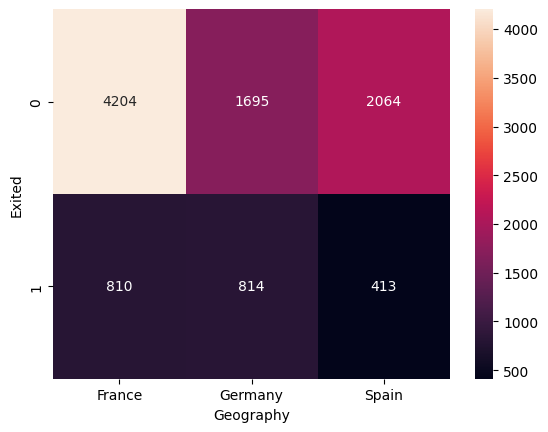

In [59]:
sns.heatmap(result,annot=True,fmt='d')
plt.show()

In [60]:
## using chi_square test to check whether two column are related or not 
#H0:There is no significant difference between geography and exited column
#H1:There is significant difference between geography and exited column

In [61]:
from scipy.stats import chi2_contingency

In [62]:
chi_score,p_value,dof,expected_value=chi2_contingency(result)
if p_value<0.05:
    print('Reject H0')
else:
    print('Fail to reject H0')

Reject H0


### Insights:
* Using visualization heatmap plot,we can analyze that geogrpahy column is related with exited column.
* We have verified that geography have significant relation with exited column using chisquare techiuqe.
* Now,we can conclude that geography is also important factor for predicting customer churn rate.

In [63]:
df.sample()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
6428,627.0,Germany,Female,39,5,124586.93,1,1,0,93132.61,1


### Gender and Exited Column Analysis 

In [64]:
result=pd.crosstab(df['Exited'],df['Gender'])

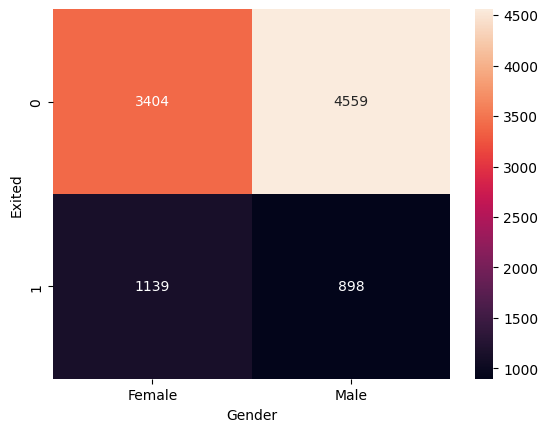

In [65]:
sns.heatmap(result,annot=True,fmt='d')
plt.show()

In [66]:
chi_score,p_value,dof,expcted=chi2_contingency(result)
if p_value<0.05:
    print('Reject H0')
else:
    print('Fail to reject H0')

Reject H0


### Insights:
* From visualization and statistics technique ,we can conlcude that there is signiificant relation between gender and exited column.
* We can conclude that gender column may be factor for predicting customer churn rate, i.e.,from analysis we can see that female have slightly greater churn rate than female

### Age and Exited column analysis

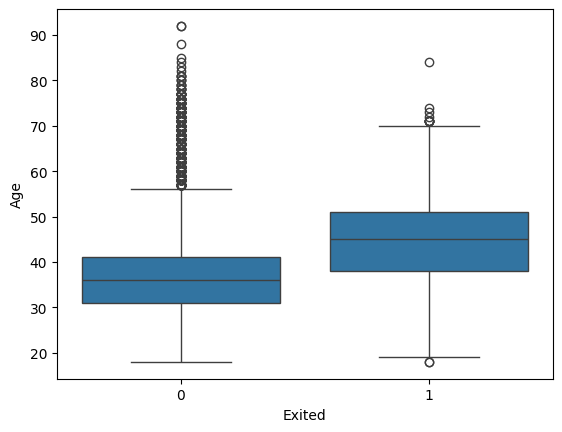

In [67]:
sns.boxplot(data=df,x='Exited',y='Age')
plt.show()

<Axes: xlabel='Age', ylabel='Density'>

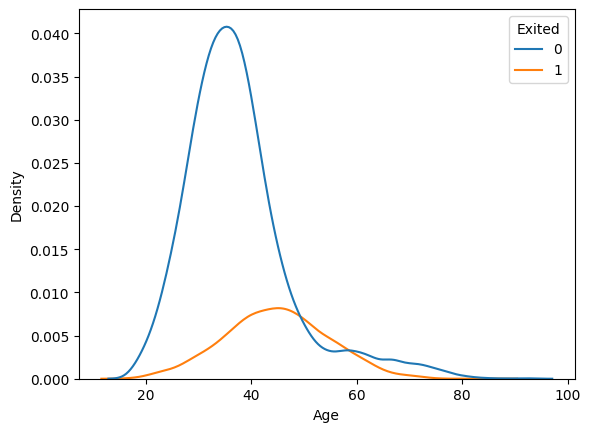

In [68]:
sns.kdeplot(data=df,x='Age',hue='Exited')

In [69]:
from scipy.stats import shapiro
from scipy.stats import levene
from scipy.stats import mannwhitneyu

In [70]:
exited_age=df[df['Exited']==1]['Age']
notexited_age=df[df['Exited']==0]['Age']
stat,p_value=mannwhitneyu(exited_age,notexited_age)
if p_value<0.05:
    print('Reject H0')
else:
    print('Fail to reject H0')

Reject H0


### Insights:
* Using visualization and statistics technique,we have conclude that age column have significant relation with Exited column.
* Thus we can conclude that age is important for predicting wheather a customer will churn a bank or not.
* Also,we have notice that,age between **(50-60)** have more churn rate than other age of customer.

In [71]:
df.sample()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9984,602.0,Germany,Male,35,7,90602.42,2,1,1,51695.41,0


### Tenure and Exited Column Analysis

In [72]:
result=pd.crosstab(df['Exited'],df['Tenure'])

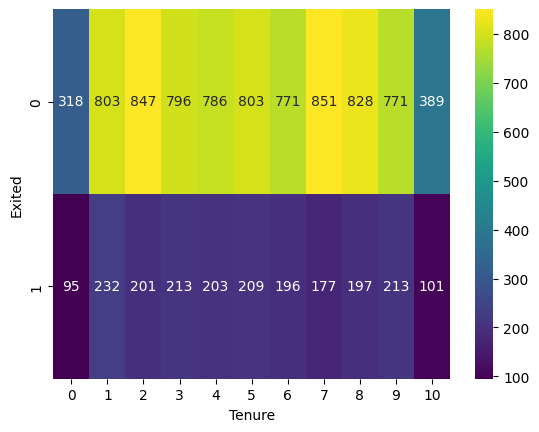

In [73]:
sns.heatmap(result,annot=True,fmt='d',cmap='viridis')
plt.show()

In [74]:
chi_score,p_value,dof,expected_value=chi2_contingency(result)
if p_value<0.05:
    print('Reject H0')
else:
    print('Fail to reject H0')
##H0:There is not relation between tenure and exited column
##H1:There is relation between tenure and exited column

Fail to reject H0


### Insights:
* Using heatmap visualization,we cannot conclude that whether a tenure is important factor for predictin churn of customer
* So,we use statistical techniue and we have seen that tenure column is not an importatn factor predicitng churn of customer.

### EstimatedSalary and Exited Column Analysis


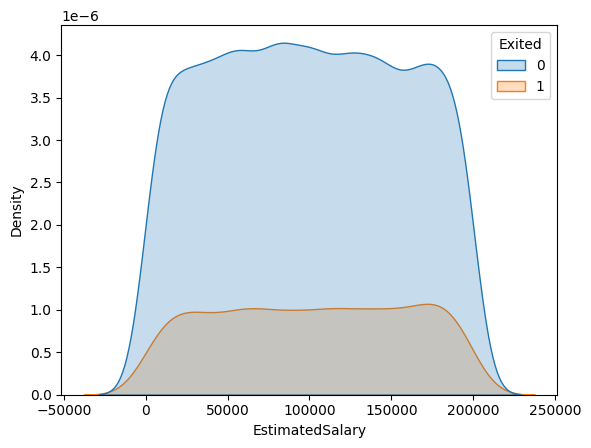

In [75]:
sns.kdeplot(data=df,x='EstimatedSalary',hue='Exited',fill=True)
plt.show()

<Axes: xlabel='Exited', ylabel='EstimatedSalary'>

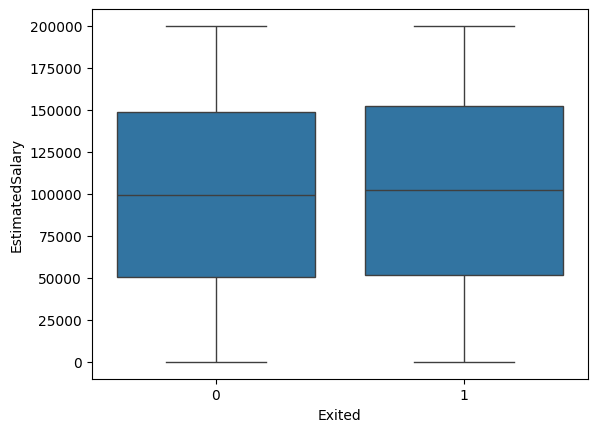

In [76]:
sns.boxplot(data=df,x='Exited',y='EstimatedSalary')

In [77]:
from scipy.stats import mannwhitneyu

exited_salary = df[df['Exited']==1]['EstimatedSalary']
notexited_salary = df[df['Exited']==0]['EstimatedSalary']

stat, p_val = mannwhitneyu(exited_salary, notexited_salary)
if p_val<0.05:
    print('Reject H0')
else:
    print('Fail to reject H0')
#H0:There is no significant realtion between esitmatedsalary and exited column
#H1:There is significant relation between estimatedsalary and exited column

Fail to reject H0


### Insights:
* From visualization such as box plot and kde plot,we can see that estimatedsalary are distributed uniformly on exited and not exited customer.
* Also,we have perform statiscs mannwhitneyau technique ,which will show that there is no significant differnce between estimatedsalary and exited column.
* We can conclude that estimated salary is not an important for predicting customer churn.

### Balance and Exited Column Analysis

<Axes: xlabel='Exited', ylabel='Balance'>

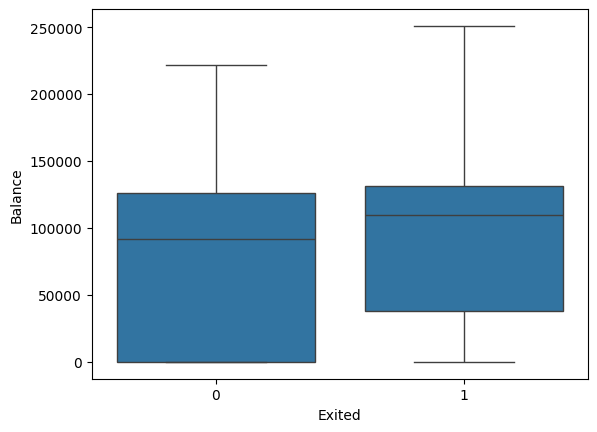

In [78]:
sns.boxplot(data=df,x='Exited',y='Balance')

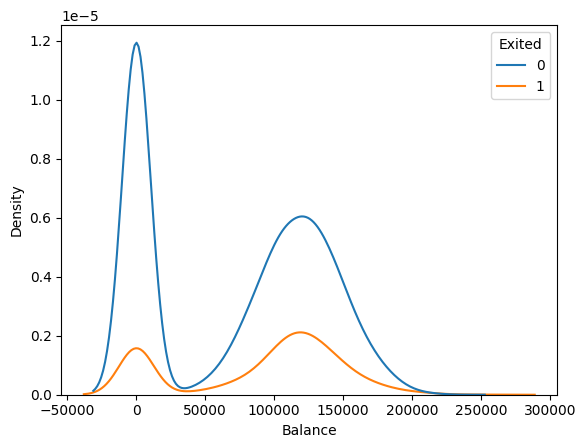

In [79]:
sns.kdeplot(data=df,x='Balance',hue='Exited')
plt.show()

In [80]:
from scipy.stats import mannwhitneyu
exited_balance=df[df['Exited']==1]['Balance']
notexited_balance=df[df['Exited']==0]['Balance']
stat_value,p_value=mannwhitneyu(exited_balance,notexited_balance)
if p_value<0.05:
    print('Reject Null Hypothesis')
else:
    print('Fail to reject null hypothesis')
#H0:There is no significant relation between exited and notexited on balance data distribution
#H1:There is significant relation between exited and notexited on balance data distribution

Reject Null Hypothesis


### Insights:
* The data distrbiution of exited and not exited customer on balance data is not same which we have seen using kdeplot and boxplot
* Also we have used statistics technique mann-whitneyu technique,to see whether there is relation between them or not and we have conclude that ther is significant relation between exited and not exited customer on balance data distribution.
* We can conclude that balance is also an important factor for predicting whether a customer will be churn or not.
* Also one noticeable point that customer having balance roughly between **(100000-150000)** have more number of churn rate.

### NumOfProducts and Exited Column Analysis

In [81]:
result=pd.crosstab(df['Exited'],df['NumOfProducts'])

<Axes: xlabel='NumOfProducts', ylabel='Exited'>

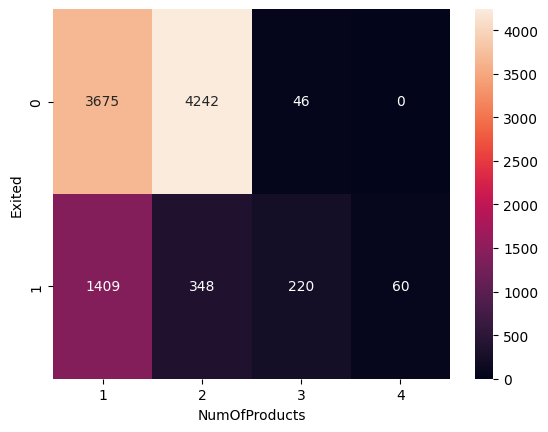

In [82]:
sns.heatmap(result,annot=True,fmt='d')

In [83]:
##Using chi_square technique to check whether there is a relation between NumOfProducts and Exited column
chi_score,p_value,dof,expted_value=chi2_contingency(result)
print(f'P_Value:{p_value}')
alpha=0.05
if p_value<alpha:
    print('Reject H0')
else:
    print('Fail to reject H0')
#H0:There is no signifcant relation between NumOfProducts and Exited Column
#H1:There is significant relation betweeen NumOfProducts and Exited Column

P_Value:0.0
Reject H0


### Insights:
* It was little surpurising that customer who are using all features of bank were  exited or churn from bank.Also customer who are using features 1,2 and 3 were also churned but not like all customer were churn like features 4. 
* Also we have use statistics chi-square technique to see wheter there is relation between NumOfProducts and Exited Column or not and we have got conclusion that there is significant relation between NumOfProducst and Exited Column.
* We can interpret it as there NumOfProducts is an important factor for predicting whether a customer will be churn or not.
  

In [84]:
df.sample()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
8301,615.0,Germany,Male,58,3,72309.3,1,1,1,85687.09,1


### HasCrCard and Exited Column Analysis

In [85]:
result=pd.crosstab(df['Exited'],df['HasCrCard'])
result

HasCrCard,0,1
Exited,,
0,2332,5631
1,613,1424


<Axes: xlabel='HasCrCard', ylabel='Exited'>

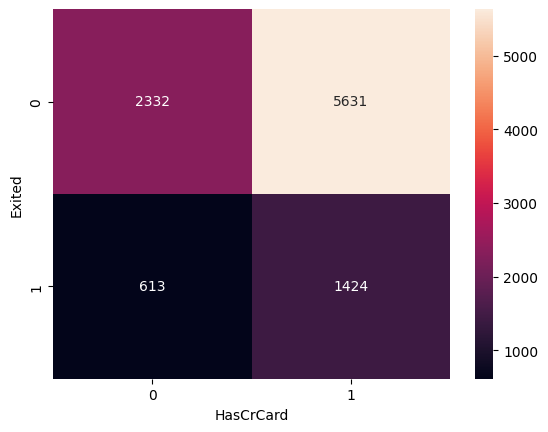

In [86]:
sns.heatmap(result,annot=True,fmt='d')

In [87]:
chi_square,p_value,dof,expcted_value=chi2_contingency(result)
if p_value<0.05:
    print('Reject H0')
else:
    print('Fail to reject H0')

Fail to reject H0


### Insights:
* using heatmap plot,we can have any idea whether HasCrCard will afect the churn of customer.So,we are using Statistics chi square test approach.
* Using chi square test,we  have conclusion that ther is no significant relation betweeen HasCrCard and Exited Column.
* We can conlude that HasCrCard is not an important factor for predicting wheather a customer will be churn or not.

### IsActiveMember and Exited Column Analysis

In [88]:
result=pd.crosstab(df['IsActiveMember'],df['Exited'])

<Axes: xlabel='Exited', ylabel='IsActiveMember'>

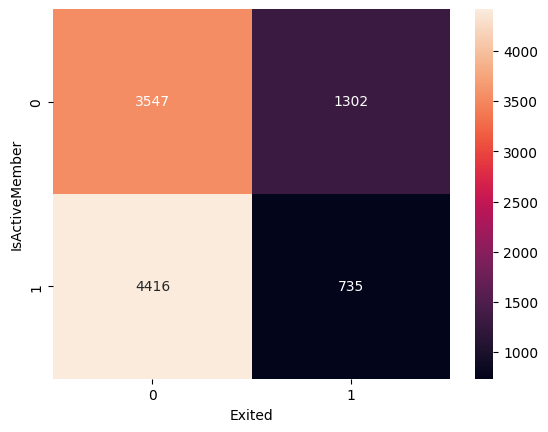

In [89]:
sns.heatmap(result,annot=True,fmt='d')

### Insights:
* Using  crosstab and heatmap plot we can conclude that the customer of bank who is not active in bank have more chance of customer to be churn than that of customer of who are active member.
* We can make conclusion that IsActiveMember column is essential for predicting whether a customer will be churn or not

### Mulitvariate Analaysis

In [90]:
df.sample()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
2597,592.0,Spain,Female,40,2,200322.45,1,1,1,113244.73,0


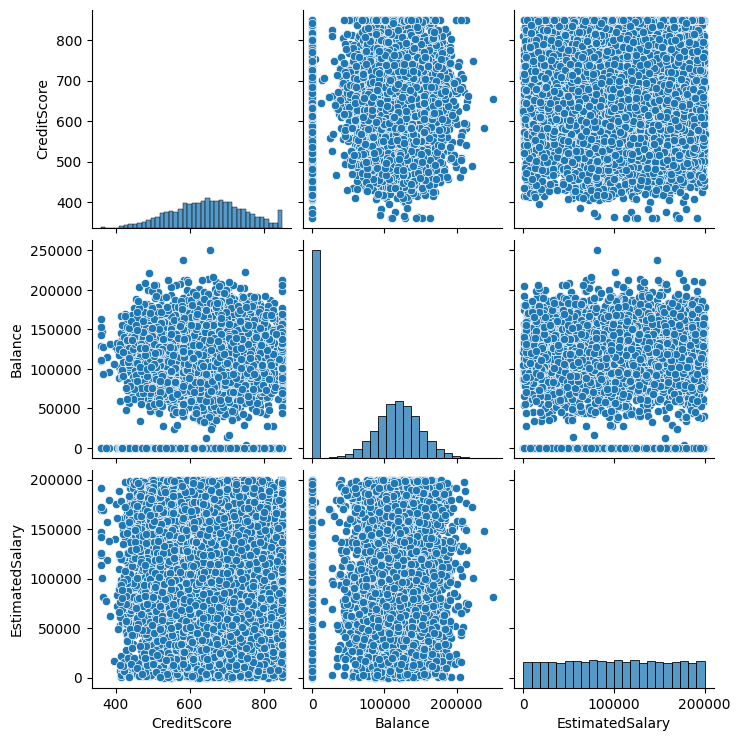

In [91]:
temp = df[['CreditScore','Balance','EstimatedSalary','Exited']]

sns.pairplot(
    temp, 
    vars=['CreditScore','Balance','EstimatedSalary']
)

In [94]:
temp.drop(columns='Exited').corr()

,CreditScore,Balance,EstimatedSalary
CreditScore,1.000000,0.006286,-0.001326
Balance,0.006286,1.000000,0.012797
EstimatedSalary,-0.001326,0.012797,1.000000


### Feature Engineering

In [4]:
def engineering_features(df):
    df=df.copy()
    df["has_3_plus_products"] = (df["NumOfProducts"] >= 3).astype(int)
    df["is_high_risk_age"] = ((df["Age"] >= 40) & (df["Age"] <= 60)).astype(int)
    df["has_zero_balance"] = (df["Balance"] == 0).astype(int)
    df["is_germany"] = (df["Geography"] == "Germany").astype(int)
    return df




In [5]:
engineering_features(df.head(5))

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,has_3_plus_products,is_high_risk_age,has_zero_balance,is_germany
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0,1,1,0
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0,1,0,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,1,0,0
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,0,1,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,1,0,0


In [6]:
X=df.drop(columns='Exited')
y=df['Exited']

### Machine Learning Portion

In [7]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [8]:
numerical_features=['CreditScore','Age','Balance','EstimatedSalary','Tenure']
categorial_features=['Geography','Gender']
binary_features=['NumOfProducts','HasCrCard','IsActiveMember','has_3_plus_products','is_high_risk_age','has_zero_balance','is_germany']

In [9]:
numericpipeline=Pipeline([
    ('impnum',SimpleImputer(strategy='mean')),
    ('sc',StandardScaler())])

In [10]:
categorialpipeline=Pipeline([
    ('impcat',SimpleImputer(strategy='most_frequent')),
    ('ohe',OneHotEncoder(handle_unknown='ignore',drop='first',sparse_output=False))])

In [11]:
preprocessor=ColumnTransformer(transformers=[
    ('num',numericpipeline,numerical_features),
    ('cat',categorialpipeline,categorial_features),
    ('bin',SimpleImputer(strategy='most_frequent'),binary_features)])

In [12]:
models={
    'LogisticRegression':LogisticRegression(max_iter=100,class_weight='balanced'),
    'SVC':SVC(class_weight='balanced'),
    'DecisionTreeClassifier':DecisionTreeClassifier(class_weight='balanced'),
    'RandomForestClassifier':RandomForestClassifier(class_weight='balanced'),
    'GradientBoostingClassifier':GradientBoostingClassifier()
}

In [13]:
result=[]

for name,model in models.items():
    pipe=Pipeline([
        ('feature_engineering',FunctionTransformer(engineering_features)),
        ('preprocessor',preprocessor),
        ('classifier',model)])
    pipe.fit(x_train,y_train)
    y_pred=pipe.predict(x_test)
    y_train_pred=pipe.predict(x_train)
    train_accuracy=accuracy_score(y_train,y_train_pred)
    test_accuracy=accuracy_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    f1=precision_score(y_test,y_pred)
    result.append({
        'model':name,
        'train_accuracy':train_accuracy,
        'test_accuracy':test_accuracy,
        'recall':recall,
        'precision':precision,
        'f1':f1
    })
        
result_df=pd.DataFrame(result)
    

In [14]:
print(result_df)

                        model  train_accuracy  test_accuracy    recall  \
0          LogisticRegression        0.772500         0.7665  0.744472   
1                         SVC        0.809625         0.7870  0.749386   
2      DecisionTreeClassifier        1.000000         0.7785  0.474201   
3      RandomForestClassifier        0.997500         0.8410  0.599509   
4  GradientBoostingClassifier        0.872375         0.8735  0.498771   

   precision        f1  
0   0.454955  0.454955  
1   0.484897  0.484897  
2   0.457346  0.457346  
3   0.611529  0.611529  
4   0.805556  0.805556  


In [15]:
param_grids={
    'classifier__n_estimators':[50,100,150,200],
    'classifier__loss':['log_loss','exponential'],
    'classifier__learning_rate':[0.01,0.05,0.1,0.2],
    'classifier__subsample':[0.5,0.6,0.7,1],
    'classifier__min_samples_split':[2,5,10,15],
    'classifier__min_samples_leaf':[1,5,10,15],
    'classifier__max_depth':[3,5,10],
    'classifier__max_features':['sqrt','log2'],
    'classifier__ccp_alpha':[0.01,0.05,0.1]}

In [16]:
grid=RandomizedSearchCV(estimator=pipe,param_distributions=param_grids,verbose=1,n_iter=50,cv=5,n_jobs=-1,scoring='f1')

In [17]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__ccp_alpha': [0.01, 0.05, ...], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__loss': ['log_loss', 'exponential'], 'classifier__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available a

In [19]:
grid.best_params_

{'classifier__subsample': 0.7,
 'classifier__n_estimators': 150,
 'classifier__min_samples_split': 10,
 'classifier__min_samples_leaf': 15,
 'classifier__max_features': 'log2',
 'classifier__max_depth': 10,
 'classifier__loss': 'exponential',
 'classifier__learning_rate': 0.05,
 'classifier__ccp_alpha': 0.01}

In [20]:
grid.best_score_

np.float64(0.466219871390883)

In [21]:
pipe=Pipeline([
    ('fe',FunctionTransformer(engineering_features)),
    ('preprocessor',preprocessor),
    ('classifier',GradientBoostingClassifier(n_estimators=50,subsample=0.5,min_samples_split=2,min_samples_leaf=15,max_depth=10,learning_rate=0.2,loss='exponential'
                                             ,ccp_alpha=0.01))])

In [22]:
weight = compute_sample_weight(class_weight='balanced', y=y_train)

In [23]:
pipe.fit(x_train,y_train,classifier__sample_weight=weight)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('fe', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['RowNumber','CustomerId','Surname',...,'HasCrCard','IsActiveMember', 'EstimatedSalary']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function eng...001C808F3BEC0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False


In [24]:
y_pred=pipe.predict(x_test)

In [25]:
accuracy_score(y_test,y_pred)

0.773

In [26]:
recall_score(y_test,y_pred)

0.7542997542997543

In [27]:
precision_score(y_test,y_pred)

0.46444780635400906

In [28]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.78      0.85      1593
           1       0.46      0.75      0.57       407

    accuracy                           0.77      2000
   macro avg       0.69      0.77      0.71      2000
weighted avg       0.83      0.77      0.79      2000



In [29]:
np.mean(cross_val_score(pipe,X,y,scoring='accuracy',cv=10))

np.float64(0.8543)

In [30]:
result=confusion_matrix(y_test,y_pred)

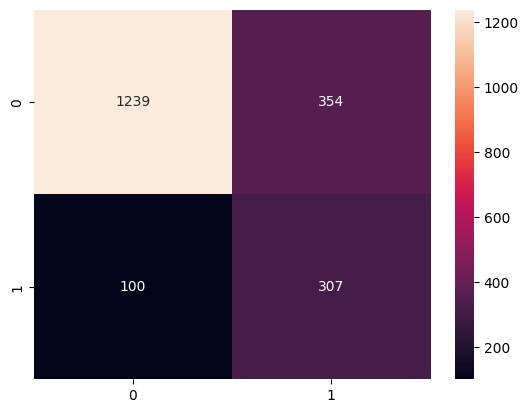

In [31]:
sns.heatmap(result,annot=True,fmt='d')
plt.show()

In [32]:
y_score=pipe.predict_proba(x_test)

In [33]:
y_score_churn=y_score[:,1]

In [34]:
precision,recall,thresholds=precision_recall_curve(y_test,y_score_churn)

In [35]:
f1_score=(2*precision*recall)/(precision+recall)

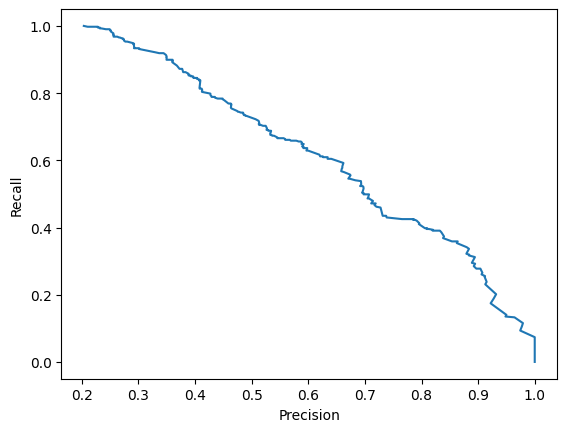

In [52]:
plt.plot(precision,recall)
plt.xlabel("Precision")
plt.ylabel("Recall")
plt.show()

In [37]:
index=np.argmax(f1_score)

In [41]:
value=thresholds[index]

In [43]:
y_pred=[1 if i>=value else 0 for i in y_score_churn]

In [44]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1593
           1       0.66      0.59      0.63       407

    accuracy                           0.86      2000
   macro avg       0.78      0.76      0.77      2000
weighted avg       0.85      0.86      0.85      2000



In [53]:
result=confusion_matrix(y_test,y_pred)

<Axes: >

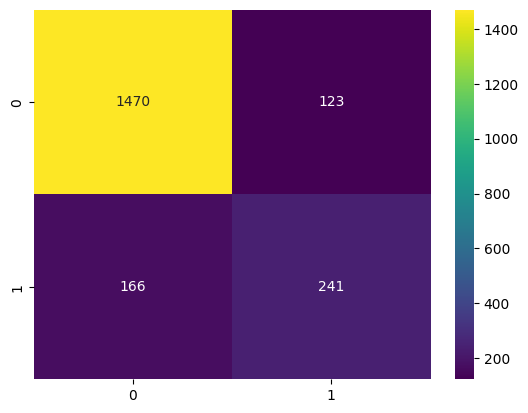

In [54]:
sns.heatmap(result,annot=True,fmt='d',cmap='viridis')

In [55]:
accuracy_score(y_test,y_pred)

0.8555

In [56]:
roc_auc_score(y_test,y_score_churn)

0.8570126366736536

In [60]:
with open('model.pkl','wb') as f:
    pickle.dump(pipe,f)